# Going deeper with Convolutional Neural Networks (`development.ipynp`)

VGG processes a grayscale image (1 channel) and compresses it into deep feature maps.
The pattern key pattern to memorise **memorise** is: Conv → ReLU → Conv → ReLU → MaxPool

Your goal is to implement the feature extraction component of a VGG-style network within the `__init__` method.

Specifications:

    Input Channels: 1 (Grayscale)

    Kernel Size: 3×3 for all convolutions (with padding=1).

    Activation: ReLU (use inplace=True) after every convolution.

    Pooling: MaxPool2d with kernel_size=2 and stride=2 at the end of every block.

Architecture:

    Block 1:

        Conv2d (1 → 64) → ReLU → Conv2d (64 → 64) → ReLU → MaxPool

    Block 2:

        Conv2d (64 → 128) → ReLU → Conv2d (128 → 128) → ReLU → MaxPool

    Block 3:

        Conv2d (128 → 256) → ReLU → Conv2d (256 → 256) → ReLU → Conv2d (256 → 256) → ReLU → MaxPool


For the optimiser, you can use `optim.Adam`

Implement this model within the file `model.py`

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

from tqdm import tqdm


torch.manual_seed(0)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

## Transform to grayscale, then to tensor, then normalise it
transform = transforms.Compose(
    [transforms.Grayscale(),
     transforms.ToTensor(),
     transforms.Normalize((0.5), (0.5)),
    ])

## Set the training and validation dataset
trainval_dataset = torchvision.datasets.ImageFolder('chest_xray/trainval', transform = transform)

## Seprate the dataset into portions 
train_portion = 0.8
val_portion = 0.2

## Assigning indexes and targets to then stratify.
all_indexes = np.arange(len(trainval_dataset))
all_targets = trainval_dataset.targets

## Split them all 
train_idx, val_idx = train_test_split(all_indexes, train_size=train_portion, stratify = all_targets, random_state = 0)

train_dataset = torch.utils.data.Subset(trainval_dataset, train_idx)
val_dataset = torch.utils.data.Subset(trainval_dataset, val_idx)

## Assign the test dataset. 
test_dataset = torchvision.datasets.ImageFolder('chest_xray/test', transform = transform)


##Assign a number of images to process for each epoch. 
batch_size = 16

trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size,
                                          shuffle=True, num_workers = 2)
valloader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size,
                                          shuffle=False, num_workers = 2)
testloader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size,
                                          shuffle=False, num_workers = 2)


In [2]:
#Check the dataset is there. 

print(f'Size of train dataset: {len(trainval_dataset)}')
print(f'Size of train dataset: {len(train_dataset)}')
print(f'Size of val dataset: {len(val_dataset)}')
print(f'Size of test dataset: {len(test_dataset)}')

Size of train dataset: 1234
Size of train dataset: 987
Size of val dataset: 247
Size of test dataset: 591


In [3]:
from model import VGG

In [31]:
# write your own training loop
## assign my model

net = VGG(num_classes = 2) 
net = net.to(device)
## Assign Loss function and optimisers 

## Cross entropy loss for classification as it 
loss_fn = nn.CrossEntropyLoss()

## Need to understand more about this one 
optmiser = optim.Adam(net.parameters(), lr=0.0001)
## Preset lopplists

nb_epochs = 40

train_loss = []
train_acc = []
val_loss = []
val_acc = []
for epoch in tqdm(range(nb_epochs), total=nb_epochs):
    ## TRAINING dataset

    epoch_loss = []
    epoch_acc=[]
    total_samples=0

    net.train()

    for inputs, labels in trainloader:
        optmiser.zero_grad()

        current_batch_size = len(labels)
        total_samples += current_batch_size

        #send data to GPU
        x = inputs.to(device)
        y = labels.to(device)

        # forward pass
        pred = net(x)

        #calc the pred class
        pred_class = torch.argmax(pred, axis=1)

        #calc the acc
        acc_tr = (pred_class ==y).sum() / len(pred_class)

        #calc the loss
        loss = loss_fn(pred, y)

        #backprop
        loss.backward()

        #update weights
        optmiser.step()

        epoch_loss += [loss.item() * current_batch_size]
        epoch_acc += [float(acc_tr.detach()) * current_batch_size]

    mean_loss = np.array(epoch_loss).sum() / total_samples
    mean_acc = np.array(epoch_acc).sum() / total_samples

    ## Validation 

    epoch_val_loss = []
    epoch_val_acc = []
    total_samples = 0

    net.eval()

    for inputs, labels in valloader:

        with torch.no_grad():

            current_batch_size = len(labels)
            total_samples += current_batch_size

            # Send data to GPU
            x = inputs.to(device)
            y = labels.to(device)

            # Forward pass
            pred = net(x)

            # Predicted class
            pred_class = torch.argmax(pred, axis=1)

            # Accuracy
            acc_val = (pred_class == y).sum() / len(pred_class)

            # Loss
            loss = loss_fn(pred, y)

            epoch_val_loss += [loss.item() * current_batch_size]
            epoch_val_acc += [float(acc_val.detach()) * current_batch_size]

    mean_val_loss = np.array(epoch_val_loss).sum() / total_samples
    mean_val_acc = np.array(epoch_val_acc).sum() / total_samples

    train_loss += [mean_loss]
    train_acc += [mean_acc]
    val_loss += [mean_val_loss]
    val_acc += [mean_val_acc]


100%|██████████| 40/40 [00:49<00:00,  1.25s/it]


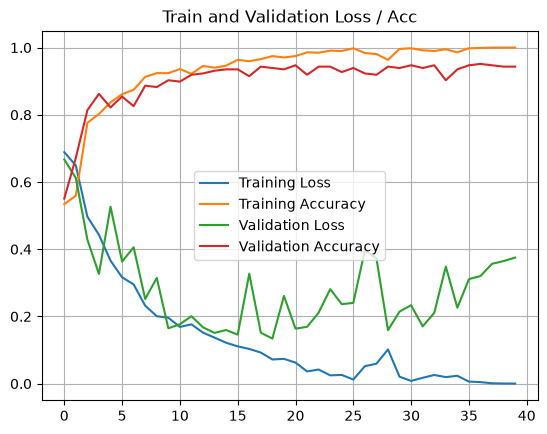

In [32]:
plt.title('Train and Validation Loss / Acc')
plt.plot(train_loss,label='Training Loss')
plt.plot(train_acc,label='Training Accuracy')
plt.plot(val_loss,label='Validation Loss')
plt.plot(val_acc,label='Validation Accuracy')
plt.legend();
plt.grid()
plt.show();

100%|██████████| 37/37 [00:00<00:00, 46.78it/s]


              precision    recall  f1-score   support

      NORMAL       0.93      0.92      0.92       278
   PNEUMONIA       0.93      0.94      0.93       313

    accuracy                           0.93       591
   macro avg       0.93      0.93      0.93       591
weighted avg       0.93      0.93      0.93       591



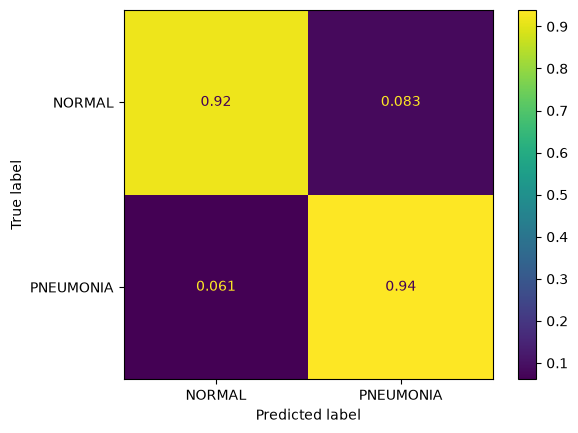

In [33]:
# Evaluation on the test set

gt_test = []
test_pred = []

# Put model into evaluation mode
net.eval()

for data in tqdm(testloader, total=len(testloader)):

    # Do not compute gradients during testing
    with torch.no_grad():

        inputs, labels = data

        # Send data to GPU
        x = inputs.to(device)
        y = labels.to(device)

        # Forward pass
        pred = net(x)

        # Predicted class
        predicted = torch.argmax(pred, dim=1)

        # Store predictions and ground truth
        test_pred.extend(predicted.cpu().tolist())
        gt_test.extend(labels.cpu().tolist())


# Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    gt_test,
    test_pred,
    display_labels=test_dataset.classes,
    normalize='true'
)

# Classification Report
from sklearn.metrics import classification_report

print(
    classification_report(
        gt_test,
        test_pred,
        target_names=test_dataset.classes
    )
)

### Save your best VGG model

In [37]:
torch.save(net.state_dict(), 'vgg.pth')

In [38]:
np.savez(
    "training_history.npz",
    train_loss=train_loss,
    train_acc=train_acc,
    val_loss=val_loss,
    val_acc=val_acc
)

### (Sanity Check!) You should be able to load the VGG model


In [35]:
from model import load_vgg

vgg = load_vgg()
vgg.eval
vgg.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU()
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=2304,